# Integrating Predictive Models with Operational Policies for Constrained Lead Qualification
This notebook reflects the coding for the masters dissertation.

In [9]:

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")



Setup complete.


In [17]:
# Loading data from google drive:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv("/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/Lead Scoring.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Upload "Lead Scoring.csv" to Colab, or load from Google Drive.


print(f"Shape: {df_raw.shape}")
print(f"Columns:\n{df_raw.columns.tolist()}")
print(f"\nConversion rate: {df_raw['Converted'].mean():.4f}")
df_raw.head()

Shape: (9240, 37)
Columns:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Conversion rate: 0.3854


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [19]:
# =============================================================================
# CELL 02 — PRESERVE RAW POLICY COLUMNS
#
# This must happen BEFORE any cleaning, grouping, or encoding.
# Policy rules (H1, H2, P1, P2, S1, S2, S3) are applied using these raw
# values. If you group rare categories first, values like "Referral" or
# "Email Link Clicked" may be collapsed into "Other" and break S3/S4.
# =============================================================================

POLICY_COLUMNS = [
    "Do Not Email",
    "Do Not Call",
    "TotalVisits",
    "Total Time Spent on Website",
    "Last Activity",
    "Lead Origin",
    "Lead Source",
    "What is your current occupation",
]

# Confirm all policy columns exist in the raw data
missing_policy = [c for c in POLICY_COLUMNS if c not in df_raw.columns]
if missing_policy:
    raise ValueError(f"Missing policy columns in raw data: {missing_policy}")

policy_df_full = df_raw[POLICY_COLUMNS].copy()

print("Raw policy columns preserved.")
print(f"\nDo Not Email value counts:\n{policy_df_full['Do Not Email'].value_counts(dropna=False)}")
print(f"\nDo Not Call value counts:\n{policy_df_full['Do Not Call'].value_counts(dropna=False)}")

Raw policy columns preserved.

Do Not Email value counts:
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

Do Not Call value counts:
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64


In [20]:

# =============================================================================
# CELL 03 — LEAKAGE REMOVAL
#
# These columns are excluded a priori, before any data inspection of their
# predictive value. They contain post-hoc human judgments or derived scores
# that are correlated with the conversion outcome and would not be available
# at the point of real-time qualification.
# =============================================================================

LEAKAGE_COLUMNS = [
    "Tags",
    "Lead Quality",
    "Asymmetrique Activity Index",
    "Asymmetrique Profile Index",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score",
]

ID_COLUMNS = ["Prospect ID", "Lead Number"]

cols_to_drop = [c for c in LEAKAGE_COLUMNS + ID_COLUMNS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).copy()

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Shape after leakage removal: {df.shape}")



Dropped 8 columns: ['Tags', 'Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'Prospect ID', 'Lead Number']
Shape after leakage removal: (9240, 29)


In [21]:

# =============================================================================
# CELL 04 — CLEAN DATA
#
# Steps:
#   a. Replace "Select" placeholder with NaN (form fields left blank by user)
#   b. Remove duplicates
#   c. Handle high-missing columns
#   d. Construct derived feature: Engagement Intensity
#   e. Note: Do Not Email / Do Not Call are NOT used as model features.
#      They are kept in the dataframe here only so they survive the split
#      alongside X. Policy rules consume them from policy_df, not from X.
# =============================================================================

# a. Replace "Select" with NaN
df = df.replace("Select", np.nan)

# b. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

# c. Drop columns with >40% missing values
missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 40].index.tolist()
print(f"\nColumns with >40% missing (will be dropped): {high_missing}")
df = df.drop(columns=high_missing)

Removed 1687 duplicate rows.

Columns with >40% missing (will be dropped): ['How did you hear about X Education', 'Lead Profile']


In [22]:

# d. Derived feature: average depth of engagement per visit
#    Captures intensity of interest rather than raw visit volume.
#    A lead with 60 minutes across 2 visits differs from one with 60 minutes
#    across 20 visits. Computed before splitting; used as a model feature only.
df["Engagement Intensity"] = (
    df["Total Time Spent on Website"] / df["TotalVisits"].replace(0, np.nan)
)
df["Engagement Intensity"] = df["Engagement Intensity"].replace(
    [np.inf, -np.inf], np.nan
)

print(f"\nShape after cleaning: {df.shape}")
print(f"\nRemaining missing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))



Shape after cleaning: (7553, 28)

Remaining missing values (top 10):
City                                             2040
What matters most to you in choosing a course    1921
What is your current occupation                  1902
Specialization                                   1844
Country                                           779
Engagement Intensity                              644
Page Views Per Visit                              136
TotalVisits                                       136
Last Activity                                     102
Lead Source                                        23
dtype: int64


Baseline conversion rate: 0.3979



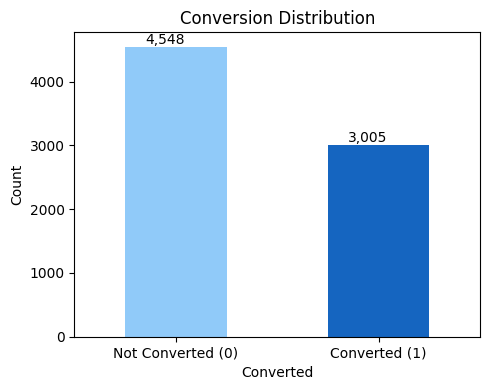

In [23]:

# =============================================================================
# CELL 05 — EDA AND POLICY JUSTIFICATION
#
# The policy rules (H1, H2, P1, P2, S1, S2, S3) are defined a priori based
# on operational logic, not derived from the data. EDA is used to describe
# and sanity-check their empirical behaviour — not to optimise them. This
# protects against the criticism that the rules were tuned to the dataset.
#
# Each chart is labelled with the rule it justifies.
# =============================================================================

BASELINE_RATE = df["Converted"].mean()
print(f"Baseline conversion rate: {BASELINE_RATE:.4f}\n")

# --- 5a. Class balance ---
fig, ax = plt.subplots(figsize=(5, 4))
df["Converted"].value_counts().plot(kind="bar", ax=ax, color=["#90CAF9", "#1565C0"])
ax.set_title("Conversion Distribution")
ax.set_xticklabels(["Not Converted (0)", "Converted (1)"], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.1, p.get_height() + 50))
plt.tight_layout()
plt.savefig("fig_01_class_balance.png", dpi=150)
plt.show()

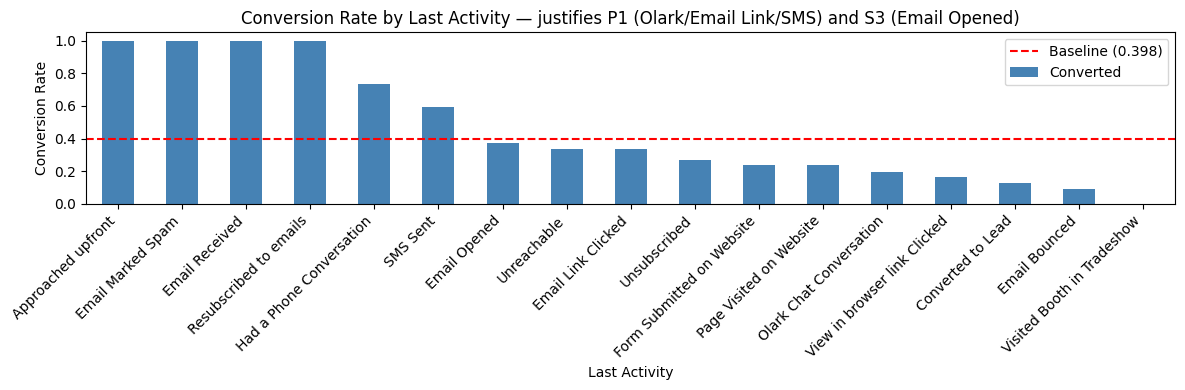

In [24]:

# --- 5b. Conversion rate by Last Activity (justifies P1, S3) ---
if "Last Activity" in df.columns:
    conv_by_activity = (
        df.groupby("Last Activity")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    conv_by_activity.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Last Activity — justifies P1 (Olark/Email Link/SMS) and S3 (Email Opened)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_02_conv_by_last_activity.png", dpi=150)
    plt.show()


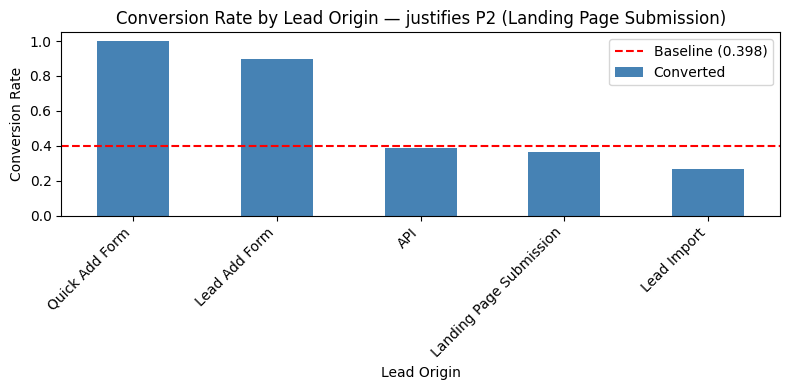

In [25]:

# --- 5c. Conversion rate by Lead Origin (justifies P2) ---
if "Lead Origin" in df.columns:
    conv_by_origin = (
        df.groupby("Lead Origin")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    conv_by_origin.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Lead Origin — justifies P2 (Landing Page Submission)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_03_conv_by_lead_origin.png", dpi=150)
    plt.show()

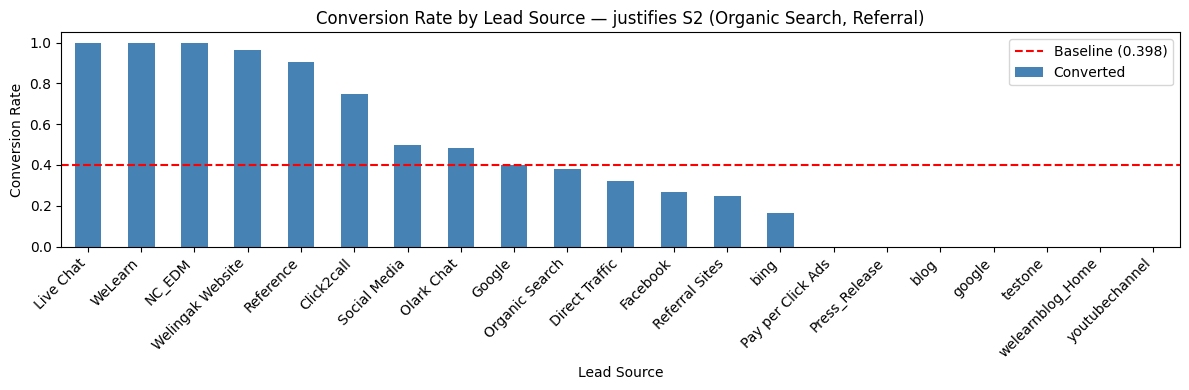

In [26]:

# --- 5d. Conversion rate by Lead Source (justifies S2) ---
if "Lead Source" in df.columns:
    conv_by_source = (
        df.groupby("Lead Source")["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    conv_by_source.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Lead Source — justifies S2 (Organic Search, Referral)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_04_conv_by_lead_source.png", dpi=150)
    plt.show()

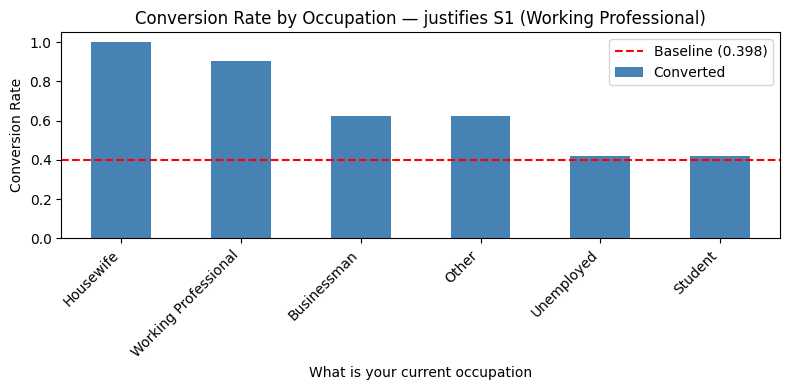

In [27]:

# --- 5e. Conversion rate by Occupation (justifies S1) ---
occ_col = "What is your current occupation"
if occ_col in df.columns:
    conv_by_occ = (
        df.groupby(occ_col)["Converted"].mean().sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    conv_by_occ.plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(BASELINE_RATE, color="red", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
    ax.set_title("Conversion Rate by Occupation — justifies S1 (Working Professional)")
    ax.set_ylabel("Conversion Rate")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("fig_05_conv_by_occupation.png", dpi=150)
    plt.show()


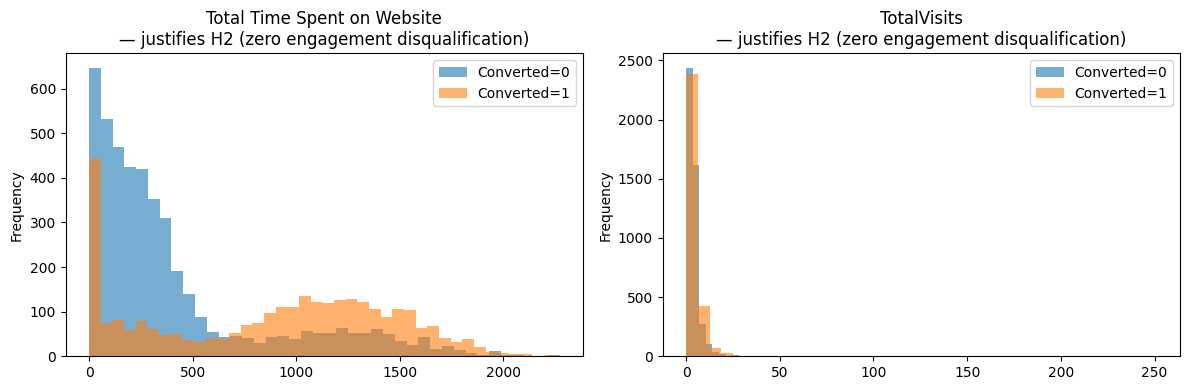

In [28]:

# --- 5f. Engagement distributions: converted vs not (justifies H2) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Total Time Spent on Website", "TotalVisits"]):
    for label, grp in df.groupby("Converted")[col]:
        grp.plot(kind="hist", bins=40, alpha=0.6, ax=ax, label=f"Converted={label}")
    ax.set_title(f"{col}\n— justifies H2 (zero engagement disqualification)")
    ax.legend()
plt.tight_layout()
plt.savefig("fig_06_engagement_distributions.png", dpi=150)
plt.show()


In [29]:

# --- 5g. Opt-out prevalence (justifies H1) ---
dne_raw = policy_df_full["Do Not Email"]
dnc_raw = policy_df_full["Do Not Call"]

dne_count = dne_raw.isin(["Yes", 1, True]).sum()
dnc_count = dnc_raw.isin(["Yes", 1, True]).sum()
both_count = (
    dne_raw.isin(["Yes", 1, True]) & dnc_raw.isin(["Yes", 1, True])
).sum()

print(f"Do Not Email flagged: {dne_count} ({dne_count/len(df)*100:.1f}%)")
print(f"Do Not Call flagged:  {dnc_count} ({dnc_count/len(df)*100:.1f}%)")
print(f"Both flagged (H1):    {both_count} ({both_count/len(df)*100:.1f}%) — these leads are disqualified")


Do Not Email flagged: 734 (9.7%)
Do Not Call flagged:  2 (0.0%)
Both flagged (H1):    0 (0.0%) — these leads are disqualified


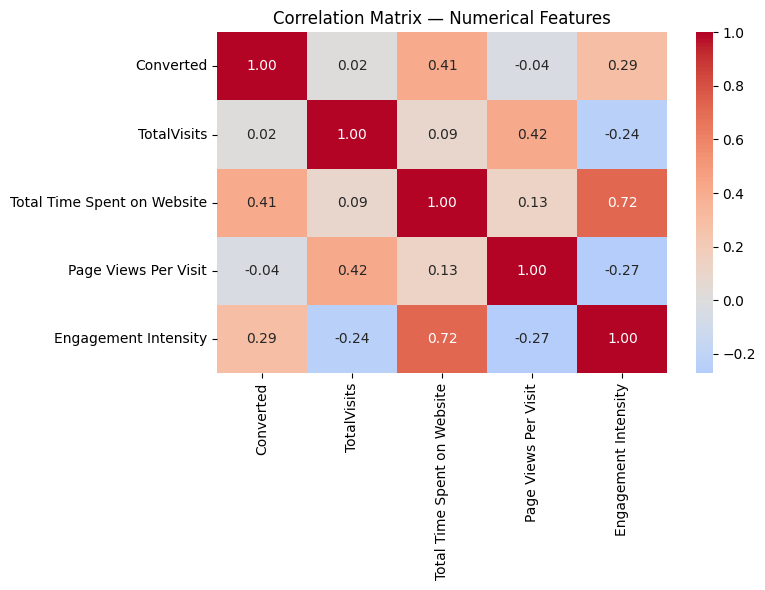

In [30]:

# --- 5h. Correlation heatmap ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.savefig("fig_07_correlation_heatmap.png", dpi=150)
plt.show()


In [31]:

# =============================================================================
# CELL 06 — TRAIN / TEST SPLIT
#
# Stratified 80/20 split preserving the conversion class distribution.
# policy_df_full is split alongside X and y to maintain index alignment.
# policy_df_full must align with df row-for-row at this point.
# =============================================================================

# Reset index after cleaning/dedup to ensure alignment
df = df.reset_index(drop=True)
policy_df_full = policy_df_full.loc[df.index].reset_index(drop=True)

TARGET = "Converted"
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X,
    y,
    policy_df_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.4f}")
print(f"Test conversion rate:  {y_test.mean():.4f}")



Train: (6042, 27)  |  Test: (1511, 27)
Train conversion rate: 0.3979
Test conversion rate:  0.3977


In [32]:

# =============================================================================
# CELL 07 — PREPROCESSING PIPELINE
#
# The pipeline is fit ONLY on training data.
# Do Not Email and Do Not Call are excluded from model features.
# They are policy signals, not predictive inputs — including them would blur
# the boundary between the ML score and the hard constraint layer.
# =============================================================================

# Exclude policy opt-out fields from model input
MODEL_EXCLUDE = ["Do Not Email", "Do Not Call"]

X_train_model = X_train.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_train.columns]
)
X_test_model = X_test.drop(
    columns=[c for c in MODEL_EXCLUDE if c in X_test.columns]
)

In [33]:

# Identify feature types
numeric_features = X_train_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_model.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")


Numeric features (4): ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Engagement Intensity']

Categorical features (21): ['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'City', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [34]:

# Preprocessing sub-pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

In [35]:

# =============================================================================
# CELL 08 — TRAIN MODELS
#
# Both models are trained on the same feature set with class weighting to
# address moderate class imbalance. Hyperparameter tuning uses 5-fold
# stratified cross-validation on the training set only.
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
logit_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

logit_params = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]}

logit_search = GridSearchCV(
    logit_pipeline,
    logit_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

logit_search.fit(X_train_model, y_train)

logit_auc = roc_auc_score(
    y_test,
    logit_search.predict_proba(X_test_model)[:, 1],
)

print(f"Logistic Regression  |  Best C: {logit_search.best_params_['model__C']}  |  Test AUC-ROC: {logit_auc:.4f}")


Logistic Regression  |  Best C: 0.1  |  Test AUC-ROC: 0.8577
